In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.special import expit

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

SEED = 314159
TRAIN_TEST_SPLIT = 0.80

data_path = "../../data/"

# Калибровка вероятностей

Часто при обучении моделей для бинарной классификации хочется получать не только предсказанную метку класса, но и вероятность положительного класса. Предсказанная вероятность может служить как мера уверенности нашего алгоритма. Также это позволяет сравнивать две модели, у которых одинаковые метрики точности. Этот тип метрик конкретно используется в высокорисковых приложениях, позволяя нам не рассматривать результаты модели как реальные вероятности, а вместо этого выходить за рамки необработанных результатов и предотвращать плохое принятие решений или ложную интерпретацию.

В задаче бинарной классификации откалиброванным алгоритмом называют такой алгоритм, для которого доля положительных примеров (на основе реальных меток классов) для предсказаний в окрестности произвольной вероятности $\hat p$ совпадает с этим значением $p$. Например, если взять объекты, для которых предсказанные вероятности близки к 0.7, то окажется, что среди них 70\% принадлежат положительному классу.
На математическом языке это выглядит так: если $\hat p$  — предсказанная вероятность класса 1, то $P(y=1|q(x_i)=\hat p)=\hat p$.

Однако некоторые алгоритмы не выдают корректные вероятности классов. В таком случае вероятности модели нужно калибровать.

Для визуализации откалиброванности алгоритма можно построить калибровочную кривую. На этой кривой абсцисса точки соответствуют значению $p$ (предсказаний алгоритма), а ордината соответствует доле примеров, для которых алгоритм предсказал вероятность, близкую к $p$. В идеальном случае эта кривая совпадает с прямой $y = x$. 

Чаще всего  $\hat p$ - это какие-то вещественные числа, которые будут разными для разных $y_i$. Для того, чтобы оценить именно вероятности, отрезок $[0, 1]$ можно разбить на бины, и для каждого бина вычислить долю класса 1 и,соответственно, среднюю предсказанную вероятность.

Пример диаграммы калибровки: 

![calib_1](../additional_materials/images/calib_1.png)


У идеально откалиброванной модели зеленая и розовая линии должны совпадать. Однако в нашем случае модель завышает свою оценку. Как отделить положительные примеры от отрицательных (дать дискретный класс)? Обычно пользуются порогом (логично сделать 0.5). Но нам придется сдвинуть порог вправо - так, чтобы разбить зеленый график пополам по вертикали.

Часто картинка иная. В таком случае говорят о слишком увернной модели (overconfident) или неуверенной (underconfident). В первом случае молдель предсказывает вероятности ближе к экстремальным, ченм стоит (0.1 вместо 0.2 и 0.9 вместо 0.1), во втором же наоборот, сводит все вероятности к центру интервала.

![calib_2](../additional_materials/images/calib_2.png)

Часто слишком большой уверенностью грешат нейросети, так как их учат именно на метках классов. Способ с этим бороться - Label smoothing, когда вместо метки класса модели дают слегка сглаженное значение (0.9 вместо 1, и т.д.). Альтернативный путь - hard samples mining, когда мы заставляем модель больше обращать внимания на объекты ближе к границе разделения.

Второй же случай возникает, если мы, наоборот, слишком сильно уделяем внимание границе. Это часто происходит в SVM или бэггинге.

Ниже на синтетическом примере посмотрим на типичные калибровочные кривые для overconfident и underconfident моделей: генерируем данные с нелинейной границей, получаем «предсказания» и искусственно искажаем их к экстремумам или к центру интервала. Кроме того, рассмотрим случай, когда модель предсказывает отношение классов, не зависящее от х.

In [35]:
from sklearn.datasets import make_moons

X_syn, y_syn = make_moons(n_samples=2000, noise=0.25, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X_syn, y_syn, test_size=0.4, random_state=SEED)
clf_syn = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
p_real = np.clip(clf_syn.predict_proba(X_te)[:, 1], 1e-6, 1 - 1e-6)

def logit(p: np.ndarray) -> np.ndarray:
    return np.log(p / (1 - p))
    
# to get new probabilities we need to make more strict logits and then return back to probas
p_over = 1. / (1 + np.exp(-5 * logit(p_real))) 
p_under = 0.5 + 0.35 * (p_real - 0.5)
p_constant = np.full_like(p_real, y_te.mean())

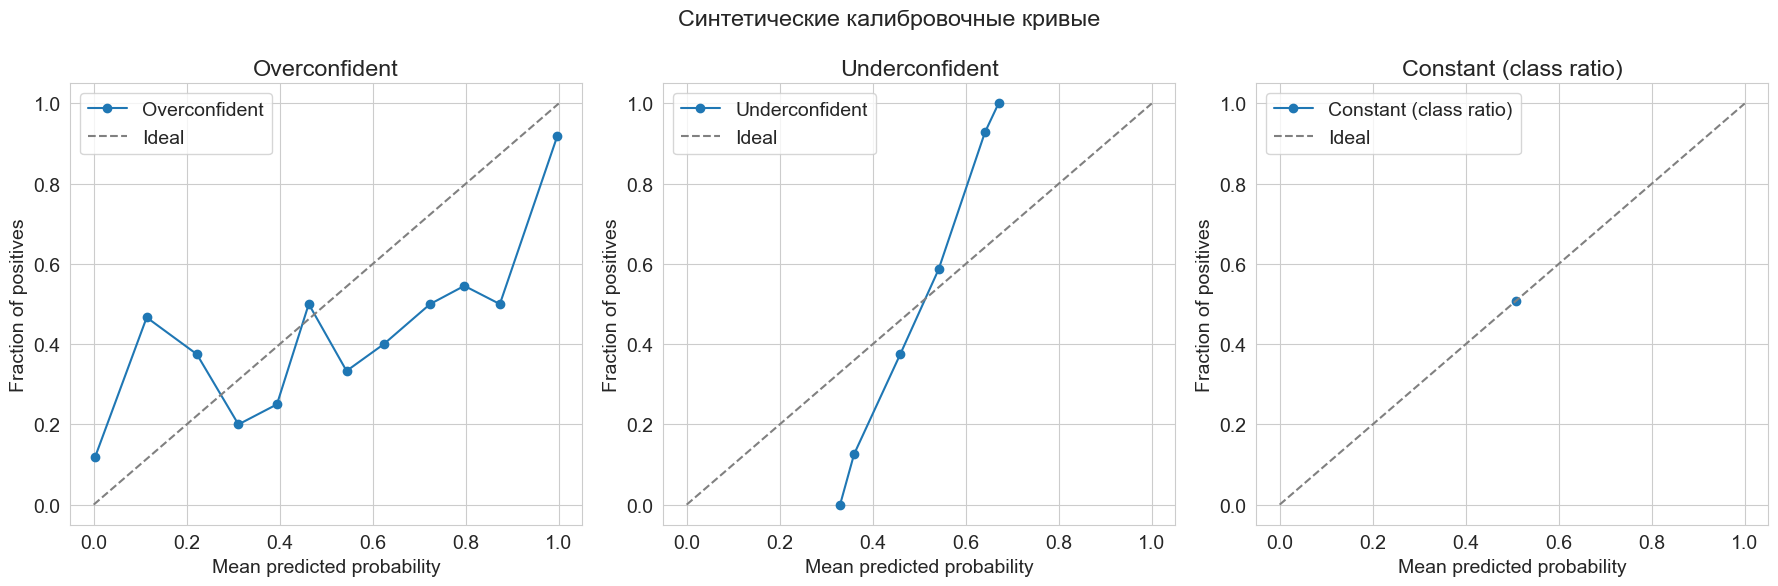

In [36]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for ax, probs, label in zip(axs, [p_over, p_under, p_constant], ['Overconfident', 'Underconfident', 'Constant (class ratio)']):
    t, p = calibration_curve(y_te, probs, n_bins=12)
    ax.plot(p, t, marker='o', label=label)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(label)
    ax.legend()
plt.suptitle('Синтетические калибровочные кривые')
plt.tight_layout()
plt.show()

In [37]:
data = pd.read_csv(data_path+'riceClassification.csv')


Отмасштабируем данные и подготовим трейн и тест.

In [38]:
X = data.drop(columns=['id', 'Class'])
y = data.Class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=999)
scaler = StandardScaler().fit(X_train, y_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

**Задание**: Оцените сбалансированность классов

In [39]:
# Задание: оцените сбалансированность классов
print('=== Баланс классов ===')
class_counts = y.value_counts()
class_props  = y.value_counts(normalize=True)

print(class_counts.to_string())
print()
print('Доли классов:')
print(class_props.apply(lambda p: f'{p:.3%}').to_string())

ratio = class_counts.max() / class_counts.min()
print(f'\nОтношение большинства к меньшинству: {ratio:.2f}:1')
if ratio < 1.5:
    print('Вывод: классы сбалансированы.')
elif ratio < 3:
    print('Вывод: умеренный дисбаланс.')
else:
    print('Вывод: значительный дисбаланс.')

=== Баланс классов ===
Class
1    9985
0    8200

Доли классов:
Class
1    54.908%
0    45.092%

Отношение большинства к меньшинству: 1.22:1
Вывод: классы сбалансированы.


Обучим метод опорных векторов (SVC — Support Vector Classification) и логистическую регрессию, в качестве метрики возьмем ROC-AUC. Для сравнения также посмотрим на градиентный бустинг.
В качестве скоров будем рассматривать выход decision_function. Этот метод возвращает confidence score для семплов и пропорционален расстоянию до разделяющей гиперплоскости, взятого со знаком. Он вернет матрицу размера (n_samples, n_classes). В бинарном случае, будет возвращен скор для класса 1.

Вопрос: Какая формула для decision function у логистической регрессии?

### Ответ: формула decision function у логистической регрессии

Decision function логистической регрессии возвращает **линейный скор** (логит) — значение до применения сигмоиды:

$$\text{decision\_function}(x) = W^\top x + b = \sum_{j=1}^d w_j x_j + b$$

Это тот же скор, что и у SVM/SVC. Чтобы получить **вероятность**, к нему применяется сигмоида:

$$P(y=1 \mid x) = \sigma(W^\top x + b) = \frac{1}{1 + e^{-(W^\top x + b)}}$$

**Граница решения** — там, где $W^\top x + b = 0$, что соответствует вероятности $P(y=1|x) = 0.5$.

Важно: `decision_function` возвращает значение в $(-\infty, +\infty)$, тогда как `predict_proba` возвращает $\sigma(\text{decision\_function}(x)) \in (0, 1)$.

In [40]:
svc = LinearSVC(max_iter=100000, C=0.1).fit(X_train, y_train)
svc_pred = svc.decision_function(X_test)
print('SVC ROC-AUC:', roc_auc_score(y_test, svc_pred))

SVC ROC-AUC: 0.9991453206707389


In [41]:
svc_pred

array([ 3.25919713,  1.95223252,  1.93751674, ...,  0.46630054,
        2.95728847, -1.77506553])

In [42]:
svc.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], dtype=int64)

In [43]:
print('SVC ROC-AUC (on predictions):', roc_auc_score(y_test, svc.predict(X_test)))

SVC ROC-AUC (on predictions): 0.9894067537906887


In [44]:
# Предскажите вероятности с помощью SVM
# LinearSVC не имеет predict_proba напрямую;
# используем decision_function + min-max нормировку (как выше)

svc_scores_raw = svc.decision_function(X_test)

# Min-max нормировка в [0, 1]
svc_proba_minmax = (svc_scores_raw - svc_scores_raw.min()) / \
                   (svc_scores_raw.max() - svc_scores_raw.min())

print('SVM decision_function (первые 5):',  svc_scores_raw[:5])
print('SVM вероятности min-max (первые 5):', svc_proba_minmax[:5])
print(f'SVM ROC-AUC (min-max): {roc_auc_score(y_test, svc_proba_minmax):.4f}')
print()
print('Примечание: min-max нормировка сохраняет порядок скоров, поэтому')
print('ROC-AUC не изменится относительно decision_function.')

SVM decision_function (первые 5): [3.25919713 1.95223252 1.93751674 1.02954277 3.28782992]
SVM вероятности min-max (первые 5): [0.71871443 0.60165813 0.60034014 0.51901883 0.72127888]
SVM ROC-AUC (min-max): 0.9991

Примечание: min-max нормировка сохраняет порядок скоров, поэтому
ROC-AUC не изменится относительно decision_function.


In [45]:
lr = LogisticRegression(max_iter=100000, C=0.1).fit(X_train, y_train)
lr_pred = lr.decision_function(X_test)
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, lr_pred))

Logistic regression ROC-AUC: 0.9990017675125695


In [46]:
gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=SEED).fit(X_train, y_train)
gb_pred = gb.decision_function(X_test) # gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, gb_pred))

Gradient Boosting ROC-AUC: 0.9983573809676445


У случайного леса нет метода decision_function, поэтому просто посмотрим на точность.

In [47]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED).fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, rf_pred))

Random Forest ROC-AUC: 0.9991008275866279


In [48]:
lr.predict(X_test)

array([1, 1, 1, ..., 1, 1, 0], dtype=int64)

In [49]:
lr.predict_proba(X_test)

array([[7.52180938e-05, 9.99924782e-01],
       [2.37484102e-03, 9.97625159e-01],
       [4.28557243e-03, 9.95714428e-01],
       ...,
       [1.72933989e-01, 8.27066011e-01],
       [2.10618110e-04, 9.99789382e-01],
       [9.98955458e-01, 1.04454161e-03]])

In [50]:
lr.classes_

array([0, 1], dtype=int64)

Судя по метрикам, мы практически идеально предсказываем класс всеми моделями.

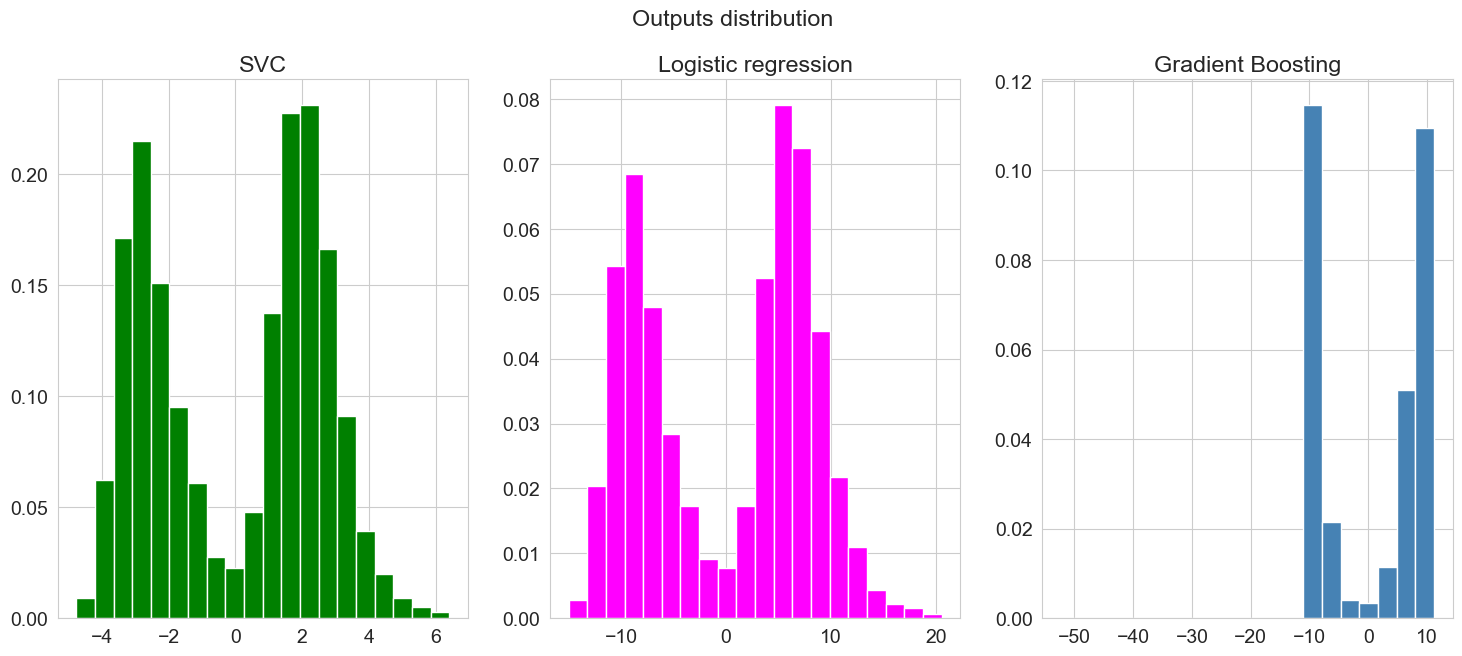

In [51]:
fig, axs = plt.subplots(1, 3, figsize=(18, 7))

axs[0].hist(svc_pred, bins=20, color='green', density='True')
axs[1].hist(lr_pred, bins=20, color='magenta', density='True')
axs[2].hist(gb_pred, bins=20, color='steelblue', density='True')

axs[0].set_title('SVC')
axs[1].set_title('Logistic regression')
axs[2].set_title('Gradient Boosting')

plt.suptitle('Outputs distribution')
plt.show()

Мы видим, что скоры могут принимать любые вещественные значения. Но для оценивания вероятностей нам нужно перевести их в промежуток 
$[0,1]$. С логистической регрессией несложно: можно добавить сигмоиду или софтмакс, ведь модель и обучалась так, чтобы $\sigma (W^Tx)$
 приближало вероятности. Для SVC у нас нет такой опции, поэтому воспользуемся масштабированием через минимум-максимум.

Вопрос: а как вычисляются вероятности для бустинга?

### Ответ: как вычисляются вероятности для бустинга?

Это зависит от реализации:

**GradientBoostingClassifier (sklearn):**
Финальный скор — сумма предсказаний всех деревьев: $F(x) = \sum_{t=1}^T \alpha_t h_t(x)$. Затем к нему применяется **сигмоида** (для бинарной задачи):
$$P(y=1 \mid x) = \sigma(F(x)) = \frac{1}{1 + e^{-F(x)}}$$
Это вытекает из того, что бустинг обучается минимизировать log-loss (deviance), где градиент соответствует разнице между предсказанной вероятностью и меткой класса.

**XGBoost / LightGBM:**
Аналогично — скор суммируется, затем к нему применяется функция связи (link function). Для бинарной классификации по умолчанию — sigmoid: $P = \sigma(\sum_t h_t(x))$.

**AdaBoost:**
Вероятность вычисляется иначе — через взвешенную сумму знаков слабых классификаторов, нормированную и переведённую через экспоненциальное взвешивание:
$$P(y=1 \mid x) = \frac{e^{F(x)}}{e^{-F(x)} + e^{F(x)}} = \sigma(2 F(x))$$

**Ключевой вывод:** у бустинга вероятности получаются через сигмоиду от накопленного скора, и они теоретически должны быть лучше откалиброваны, чем у SVM или Random Forest.

In [52]:
svc_pred = (svc_pred - svc_pred.min()) / (svc_pred.max() - svc_pred.min())
lr_pred = lr.predict_proba(X_test)[:, 1]
gb_pred = gb.predict_proba(X_test)[:, 1]
rf_pred = rf.predict_proba(X_test)[:, 1]

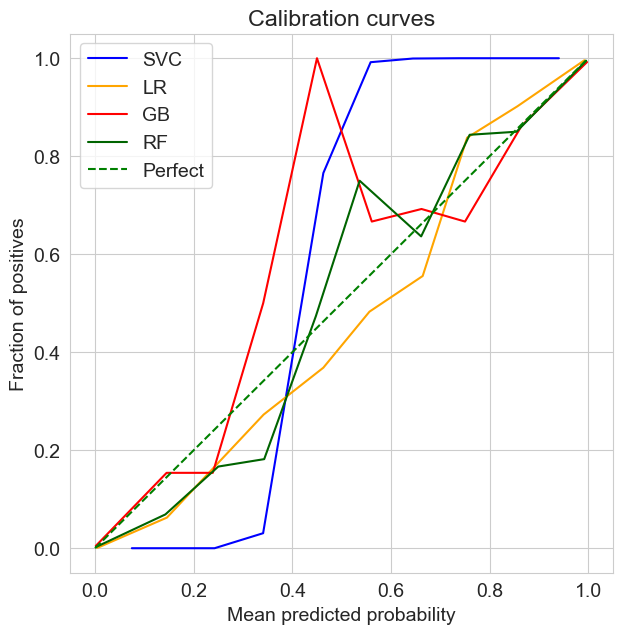

In [53]:
plt.figure(figsize=(7, 7))

svc_true_prob, svc_pred_prob = calibration_curve(y_test, svc_pred, n_bins=10)
lr_true_prob, lr_pred_prob = calibration_curve(y_test, lr_pred, n_bins=10)
gb_true_prob, gb_pred_prob = calibration_curve(y_test, gb_pred, n_bins=10)
rf_true_prob, rf_pred_prob = calibration_curve(y_test, rf_pred, n_bins=10)

plt.plot(svc_pred_prob, svc_true_prob, label='SVC', color='blue')
plt.plot(lr_pred_prob, lr_true_prob, label='LR', color='orange')
plt.plot(gb_pred_prob, gb_true_prob, label='GB', color='red')
plt.plot(rf_pred_prob, rf_true_prob, label='RF', color='darkgreen')
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='green')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves')
plt.legend()
plt.show()


Мы видим, что кривая для логистической регрессии неплохо приближает диагональ, при этом в бустинге можно вообразить чрезмерную уверенность. С SVC все гораздо хуже. Но попробуем откалибровать модели разными способами.

Что интересно с ансамблями: у них есть явный горб посередине интервала. Это значит, что моделям в принципе сложновато предсказывать крайние значения вероятностей. Хорошее объяснение этому дано в [статье](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf), цитата из нее: 
> Methods such as bagging and random forests that average predictions from a base set of models can have difficulty making predictions near 0 and 1 because variance in the underlying base models will bias predictions that should be near zero or one away from these values. Because predictions are restricted to the interval [0,1], errors caused by variance tend to be one-sided near zero and one. 

> For example, if a model should predict $p=0$ for a case, the only way bagging can achieve this is if all bagged trees predict zero. If we add noise to the trees that bagging is averaging over, this noise will cause some trees to predict values larger than 0 for this case, thus moving the average prediction of the bagged ensemble away from 0. We observe this effect most strongly with random forests because the base-level trees trained with random forests have relatively high variance due to feature subsetting.”

Другой способ визуализировать то же самое - диаграмма надёжности (reliability diagram):

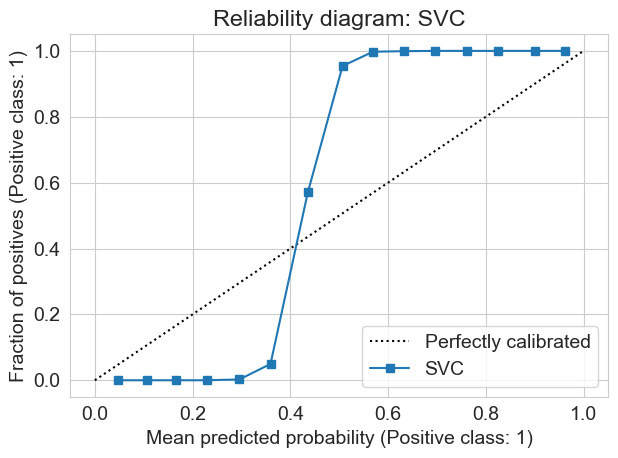

In [54]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, svc_pred, n_bins=15, name='SVC')
plt.title('Reliability diagram: SVC')
plt.tight_layout()
plt.show()

**Задание**: Постройте гистограмму предсказанных вероятностей для двух классификаторов.

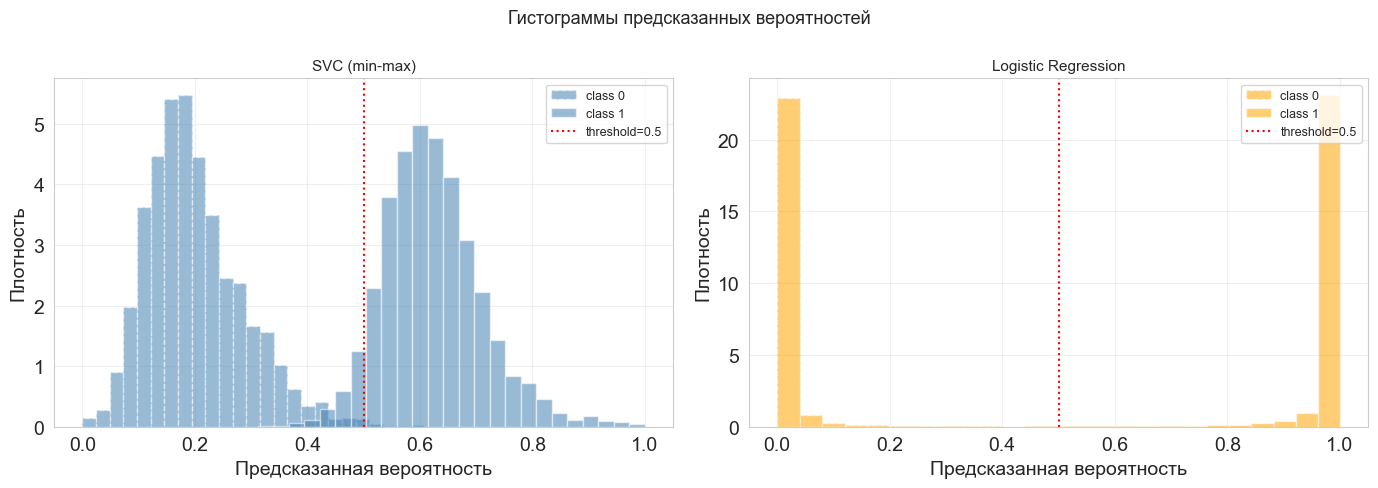

In [55]:
# Задание: гистограмма предсказанных вероятностей для двух классификаторов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Гистограммы предсказанных вероятностей', fontsize=13)

for ax, probs, title, color in zip(
    axes.ravel(),
    [svc_pred, lr_pred],
    ['SVC (min-max)', 'Logistic Regression'],
    ['steelblue', 'orange']
):
    for cls, ls, lbl in [(0, '--', 'class 0'), (1, '-', 'class 1')]:
        ax.hist(probs[y_test == cls], bins=25, alpha=0.55,
                density=True, color=color, linestyle=ls, label=lbl)
    ax.axvline(0.5, color='red', linestyle=':', linewidth=1.5, label='threshold=0.5')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Предсказанная вероятность')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Калибровка Платта
Пусть наш алгоритм выдаёт значения $f(x)$ (могут не быть вероятностями). Тогда итоговая вероятность строится как:

$$P(y = 1 | x) = \frac{1}{1+\exp (af(x) + b)},$$

где $a, b$ -- скалярные параметры. Эти параметры настраиваются методом максимума правдоподобия (минимизируя логистическую функцию потерь):
$$- \sum_{i=1}^N[y_i \log{(\sigma(af(x_i)+b))} + (1 - y_i) \log{(1-\sigma(af(x_i)+b))}] \to min_{a,b}$$

Алгоритм: на выходах $f(x)$ базовой модели обучается логистическая регрессия без регуляризации; откалиброванное предсказание — $\sigma(af(x)+b)$.

Вопрос: на какой выборке обучается модель?

Также Платт предложил для избежания переобучения изменить метки объектов в NLL ($y_i$ и $1-y_i$) на следующие значения:

$t_{+} = \frac{N_{+} + 1}{N_{-} + 2}$ для положительных примеров и

$t_{-} = \frac{1}{N_{-} + 2}$ для отрицательных, где $N_{-}$ и $N_{+}$ число негативных и позитивных семплов в выборке. 

Калибровку Платта можно представить как применение логистической регрессии поверх предсказаний другого алгоритма с отключенной регуляризацией. 

Калибровка Платта неплохо справляется с SVM, но для более хитрых классификаторов может спасовать. В целом, можно показать, что этот метод хорошо работает, если для каждого из истинных классов предсказанные вероятности распределены нормально с одинаковыми дисперсиями (подробнее [здесь](https://research-information.bris.ac.uk/ws/portalfiles/portal/154625753/Full_text_PDF_final_published_version_.pdf)). 

Вообще эта калибровка относится к большой группе параметрических методов калибрации, туда же относится бета-калибрация (в предположении бета-распределения) или калибрация Дирихле (для мультикласса). 

### Ответ: на какой выборке обучается модель Платта?

Калибровочная модель (логистическая регрессия Платта) обучается на отдельной выборке — не на той, на которой обучалась базовая модель.

Причина: если обучать калибровку на тренировочных данных, то базовая модель уже «видела» их и предсказывает почти идеально → калибровочная LR подстроится под завышенную уверенность, а не под реальное распределение вероятностей.

In [56]:
sigmoid_svc = CalibratedClassifierCV(svc, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_svc_pred = sigmoid_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, sigmoid_svc_pred))

SVC ROC-AUC: 0.9991337204155334


In [57]:
sigmoid_lr = CalibratedClassifierCV(lr, cv=3, method='sigmoid').fit(X_train, y_train)# YOUR CODE: make the same for LR
sigmoid_lr_pred = sigmoid_lr.predict_proba(X_test)[:, 1]
print('Logistic regression ROC-AUC:', roc_auc_score(y_test, sigmoid_lr_pred))

Logistic regression ROC-AUC: 0.9989783380497528


In [58]:
sigmoid_rf = CalibratedClassifierCV(rf, cv=3, method='sigmoid').fit(X_train, y_train)# YOUR CODE: make the same for LR
sigmoid_rf_pred = sigmoid_rf.predict_proba(X_test)[:, 1]
print('LRandom forest ROC-AUC:', roc_auc_score(y_test, sigmoid_rf_pred))

LRandom forest ROC-AUC: 0.999082664029135


In [59]:
sigmoid_gb = CalibratedClassifierCV(gb, cv=3, method='sigmoid').fit(X_train, y_train)
sigmoid_gb_pred = sigmoid_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, sigmoid_gb_pred))

Gradient Boosting ROC-AUC: 0.9990612569792324


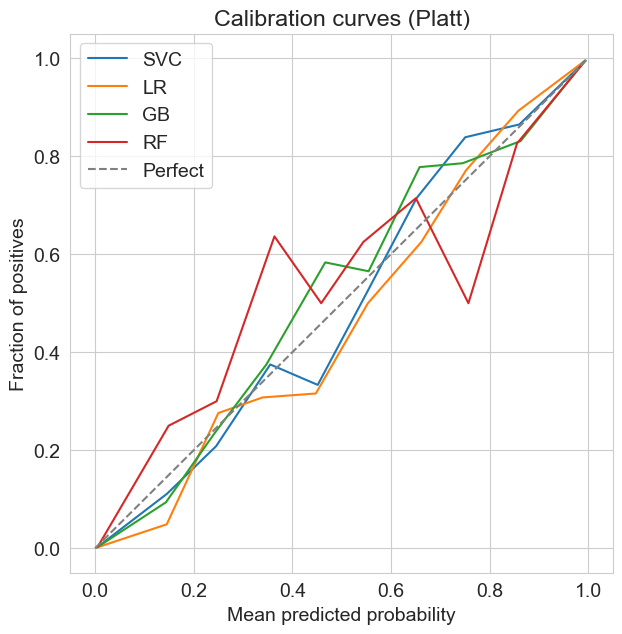

In [60]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', sigmoid_svc_pred), ('LR', sigmoid_lr_pred), ('GB', sigmoid_gb_pred), ('RF', sigmoid_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Platt)')
plt.legend()
plt.show()

Как мы видим, калибровка Платта действительно улучшила вероятности, который получаются у SVC, RF и GB. При этом кривая для логистической регрессии практически не сдвигается. 

# Изотоническая регрессия
В этом методе также строится отображение из предсказаний модели в откалиброванные вероятности. Используется изотоническая функция: неубывающая, кусочно-постоянная; $x$ — выходы алгоритма, $y$ — целевая переменная. 

Мы хотим найти такую функцию $m(t)$: $P(y = 1 | x) = m(f(x))$. Она настраивается под квадратичную ошибку:

$$m = \arg \min_{z} \sum (y_i - z(f(x_i))^2,$$

с помощью специального алгоритма (Pool-Adjacent-Violators Algorithm):

---
*Вход: обучающая выборка — пары (скор модели $f_i$, метка $y_i \in \{0,1\}$), отсортированные по возрастанию $f_i$.*

Для каждой точки $i$ задаём один сегмент: оценка вероятности сегмента $m_{i,i} = y_i$ (метка точки), вес сегмента $w_{i,i} = 1$.

В цикле, пока есть нарушение изотонности — два соседних сегмента $(k, i-1)$ и $(i, l)$, у которых $m_{k,i-1} \geq m_{i,l}$ — объединяем их в один $(k, l)$: новый вес $w_{k,l} = w_{k,i-1} + w_{i,l}$, новая оценка $m_{k,l} = (w_{k,i-1} m_{k,i-1} + w_{i,l} m_{i,l}) / w_{k,l}$; заменяем два старых сегмента одним и повторяем.

*Выход: кусочно-постоянная функция $m(f)$: для любого скора $f$ значение $m(f)$ — это $m_{i,j}$ того сегмента $(i,j)$, в диапазон которого попадает $f$.*

---

В результате калибровки получаем надстройку над нашей моделью, которая применяется поверх предсказаний базовой модели. В случае мультиклассовой классификации каждый класс калибруется отдельно против остальных (one-versus-all), вероятности при предсказании нормируются.

Этот метод более общий, чем калибровка Платта, так как единственное условие для калибровочной функции - чтобы она была изотонической. Этот метод склонен к переобучению, поэтому его рекомендуется применять только для больших выборок.


In [61]:
isotonic_svc = CalibratedClassifierCV(svc, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_svc_pred = isotonic_svc.predict_proba(X_test)[:, 1]
print('SVC ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

SVC ROC-AUC: 0.9990992249197903


In [62]:
# YOUR CODE: Make the same for LR
isotonic_lr = CalibratedClassifierCV(lr, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_lr_pred = isotonic_lr.predict_proba(X_test)[:, 1]
print('LR ROC-AUC:', roc_auc_score(y_test, isotonic_svc_pred))

LR ROC-AUC: 0.9990992249197903


In [63]:
isotonic_gb = CalibratedClassifierCV(gb, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_gb_pred = isotonic_gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, isotonic_gb_pred))

Gradient Boosting ROC-AUC: 0.998995204210282


In [64]:
isotonic_rf = CalibratedClassifierCV(rf, cv=3, method='isotonic').fit(X_train, y_train)
isotonic_rf_pred = isotonic_rf.predict_proba(X_test)[:, 1]
print('Random Forest ROC-AUC:', roc_auc_score(y_test, isotonic_rf_pred))

Random Forest ROC-AUC: 0.9991284163514756


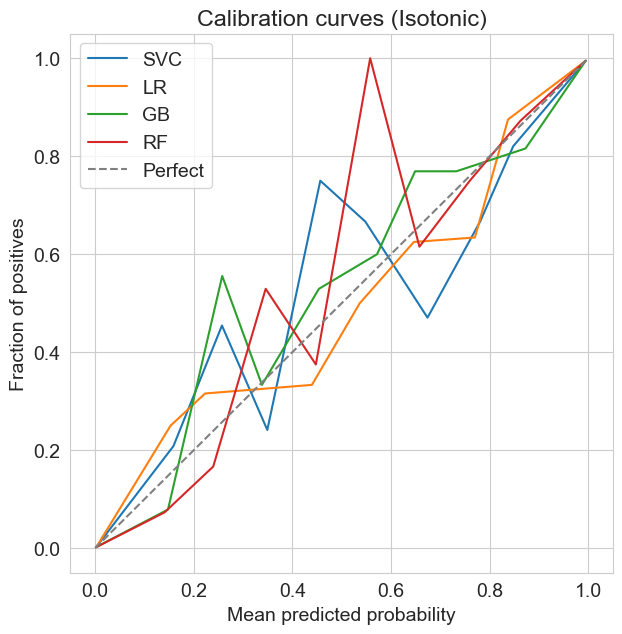

In [65]:
plt.figure(figsize=(7, 7))
for name, pred in [('SVC', isotonic_svc_pred), ('LR', isotonic_lr_pred), ('GB', isotonic_gb_pred), ('RF', isotonic_rf_pred)]:
    true_prob, pred_prob = calibration_curve(y_test, pred, n_bins=10)
    plt.plot(pred_prob, true_prob, label=name)
plt.plot([0, 1], [0, 1], label='Perfect', linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curves (Isotonic)')
plt.legend()
plt.show()

Изотоническая регрессия немного подпортила кривую калибрации для моделей. Судя по всему, олна переобучилась.

## Мультикласс
У нас есть как минимум три варианта определить, что означает мультиклассовая калиброванность. Например, по мере увеличения строгости:
1) Учитывать только самую высокую вероятность. Для него мы требуем, чтобы среди всех случаев, где вероятность наиболее вероятного класса прогнозируется как $c$, ожидаемая точность была бы $c$. $P(Y=i|\hat p_i(x)=q_i)=q_i, i=\arg\max_j \hat p_j (X)$
2) Учитывать маргинальные вероятности. Тут мы хотим, чтобы все one-vs-rest вероятности были откалиброваны: $P(Y=i|\hat p_i(x)=q_i)=q_i, i=1...k$.
3) Учитывать весь вектор вероятностей. Т.е. чтобы пропорции классов для семплов с определенным вектором предсказаний былит такие же, как и весь вектор предсказаний:  $P(Y=i|\hat p(x)=q)=q_i, i=1...k$. 
   
Чаще всего используется определение слабой калиброванности (1). Однако, в случае чувствительной к стоимости постановки задачи оно может быть слишком слабым.


## Оценка качества калибровки

Мы что-то поняли по графикам, но как оценить численно улучшение предсказания вероятностей? Для этого есть свои метрики.

**Maximum calibration error**. Самый простой способ, впрочем — он наследник идеи с калибровочной кривой. А именно, разобьём отрезок 
$[0,1]$ на бины $B_1, B_2, ..., B_k$ по предсказанным вероятностям $\overline y(x_i)$ и вычислим следующее:
$$ \max_{j=1,..,k}|{\overline y(B_k) - \overline q (B_k) }|$$
Где $\overline y(B_k) $ - средняя предсказанная вероятность, $ \overline q (B_k) $ - среднее значение уверенности.

**Expected Calibration Error (ECE)** считает среднюю разницу: $$ \sum^k_{j=1}{{\|B_j\|}\over{N}}{| {\overline y(B_k) - \overline q (B_k) }|},$$
где $\|B_j\|$ - число семплов в бине. Бинны обычно строят равными по длине отрезка $[0,1]$ (uniform) или по квантилям предсказаний (quantile); веса $|B_j|/N$ делают вклад каждого бина пропорциональным его размеру.

Проблема этих способов в том, что мы можем очень по-разному предсказывать в каждом из бинов вероятности (в том числе константой) без ущерба для метрики.

Применим метрику калибрации:

In [66]:
def binary_ECE(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        low, high = bin_edges[i], bin_edges[i + 1]
        mask = (y_prob >= low) & (y_prob <= high) if i == n_bins - 1 else (y_prob >= low) & (y_prob < high)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() * np.abs(acc - conf)
    return ece / n

print("Platt:")
print('SVC binary-ECE = ', binary_ECE(y_test, sigmoid_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, sigmoid_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, sigmoid_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, sigmoid_rf_pred))

print("Isotonic:")
print('SVC binary-ECE = ', binary_ECE(y_test, isotonic_svc_pred))
print('Linear binary-ECE = ', binary_ECE(y_test, isotonic_lr_pred))
print('GB binary-ECE = ', binary_ECE(y_test, isotonic_gb_pred))
print('RF binary-ECE = ', binary_ECE(y_test, isotonic_rf_pred))

Platt:
SVC binary-ECE =  0.0027822956798103093
Linear binary-ECE =  0.003447746060042662
GB binary-ECE =  0.003472623806893145
RF binary-ECE =  0.002610568433671964
Isotonic:
SVC binary-ECE =  0.002086450807310024
Linear binary-ECE =  0.0021506234269813708
GB binary-ECE =  0.002283717139315842
RF binary-ECE =  0.002056138427129562


Может быть такое, что метрики показывают нам иную картину, чем графики. Возможно, дело в том, что мы делали графики без учета числа семплов в бинах (а резкие прыжки могут значить, что семплов маловато). 

**Задание**: постройте калибровочные кривые для адаптивных бинов (strategy=‘quantile’) и сравните графики для разных калибровок с ними.

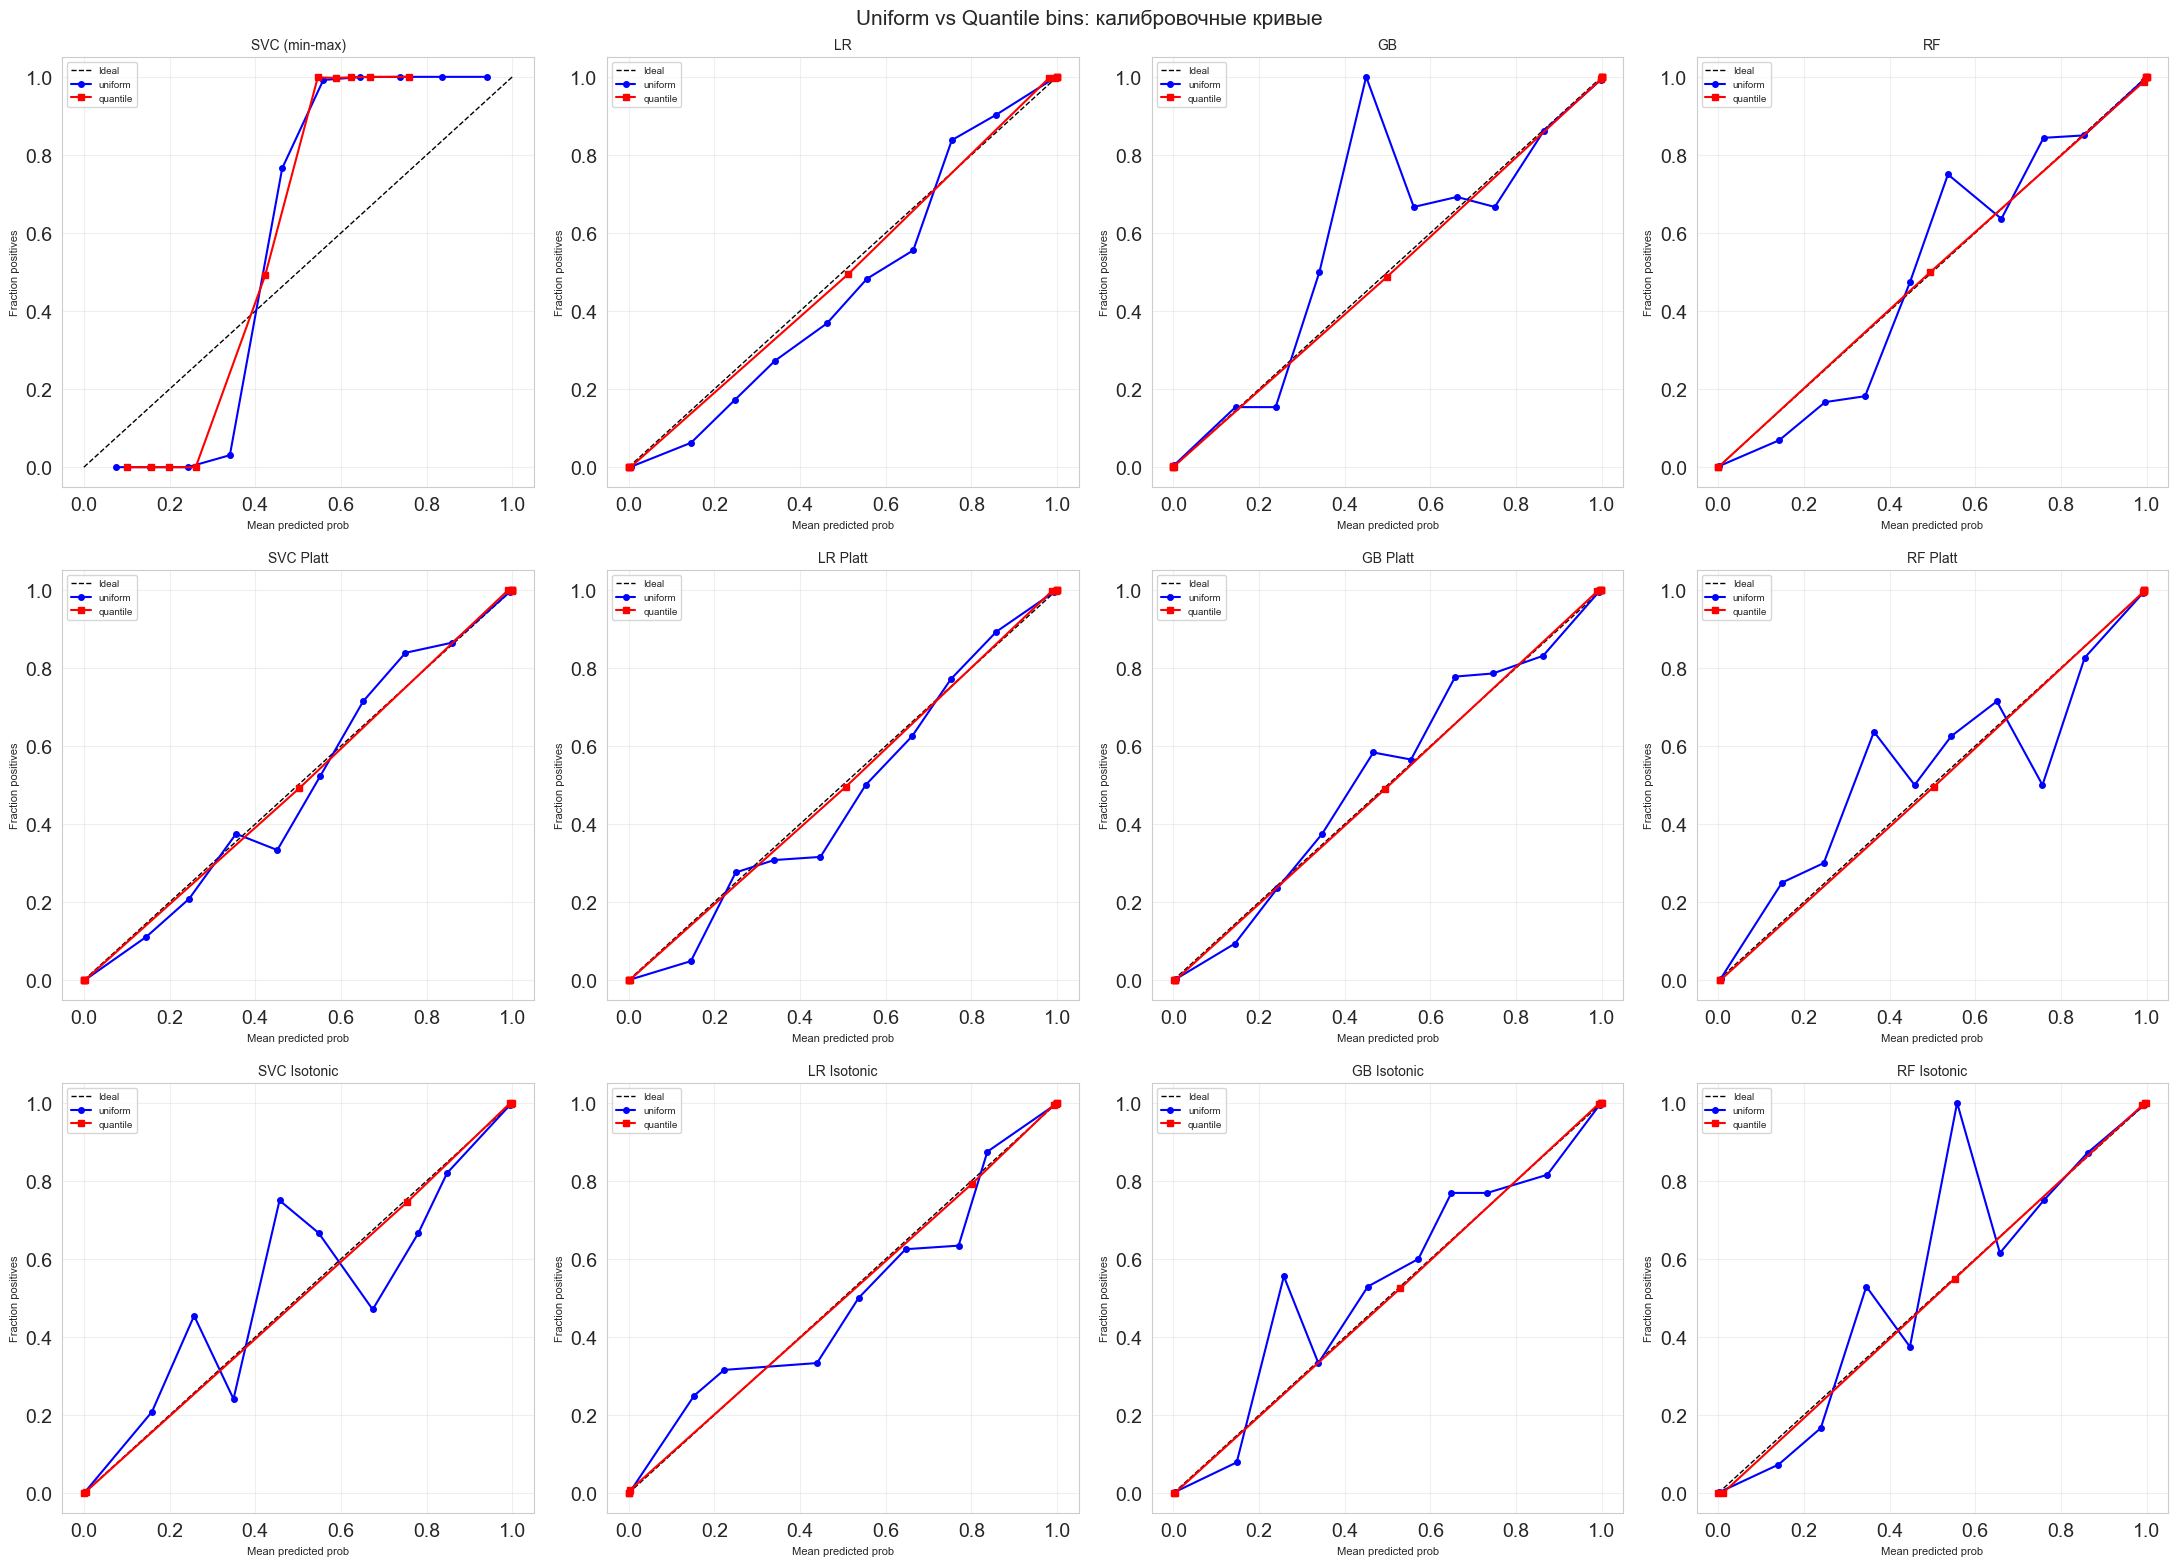

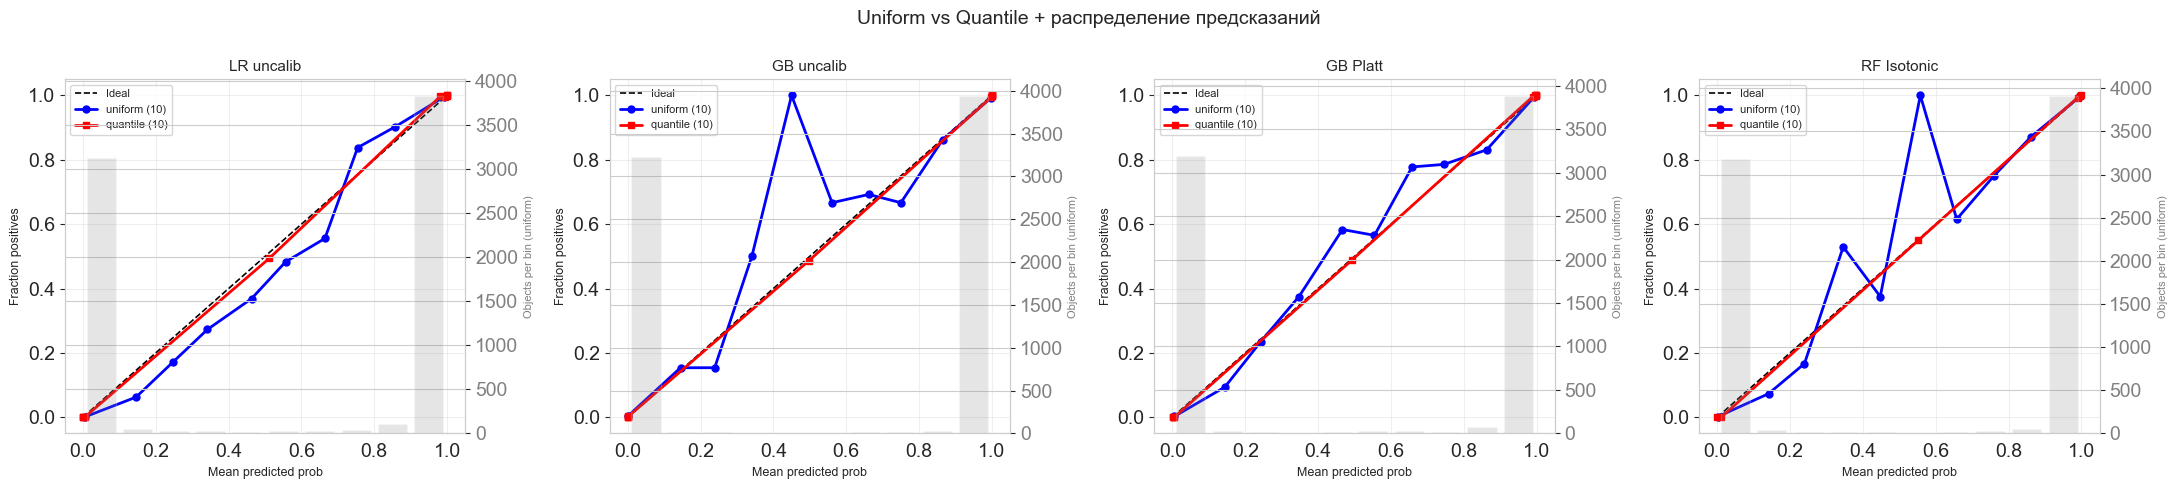

In [67]:
# --- 1. Общий обзор: Uniform vs Quantile для всех моделей ---
fig, axes = plt.subplots(3, 4, figsize=(22, 16))
fig.suptitle('Uniform vs Quantile bins: калибровочные кривые', fontsize=15)

# Создаем список моделей для сравнения
models_to_compare = [
    ('SVC (min-max)', svc_pred),
    ('LR', lr_pred),
    ('GB', gb_pred),
    ('RF', rf_pred),
    ('SVC Platt', sigmoid_svc_pred),
    ('LR Platt', sigmoid_lr_pred),
    ('GB Platt', sigmoid_gb_pred),
    ('RF Platt', sigmoid_rf_pred),
    ('SVC Isotonic', isotonic_svc_pred),
    ('LR Isotonic', isotonic_lr_pred),
    ('GB Isotonic', isotonic_gb_pred),
    ('RF Isotonic', isotonic_rf_pred),
]

for ax, (name, pred) in zip(axes.ravel(), models_to_compare):
    tp_u, pp_u = calibration_curve(y_test, pred, n_bins=10, strategy='uniform')
    tp_q, pp_q = calibration_curve(y_test, pred, n_bins=10, strategy='quantile')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Ideal')
    ax.plot(pp_u, tp_u, 'b-o', ms=4, lw=1.5, label='uniform')
    ax.plot(pp_q, tp_q, 'r-s', ms=4, lw=1.5, label='quantile')

    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Mean predicted prob', fontsize=8)
    ax.set_ylabel('Fraction positives', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# --- 2. Детальное сравнение: 4 модели + распределение ---
highlight = [
    ('LR uncalib',   lr_pred,          'orange'),
    ('GB uncalib',   gb_pred,          'green'),
    ('GB Platt',     sigmoid_gb_pred,  'limegreen'),
    ('RF Isotonic',  isotonic_rf_pred, 'purple'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Uniform vs Quantile + распределение предсказаний', fontsize=14)

for ax, (name, pred, color) in zip(axes, highlight):
    tp_u, pp_u = calibration_curve(y_test, pred, n_bins=10, strategy='uniform')
    tp_q, pp_q = calibration_curve(y_test, pred, n_bins=10, strategy='quantile')

    # uniform bin counts (для визуализации)
    edges = np.linspace(0, 1, 11)
    counts = np.histogram(pred, bins=edges)[0]

    ax2 = ax.twinx()
    ax2.bar(edges[:-1] + 0.05, counts, width=0.08, alpha=0.2, color='gray')
    ax2.set_ylabel('Objects per bin (uniform)', fontsize=8, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Ideal')
    ax.plot(pp_u, tp_u, 'b-o', ms=5, lw=2, label='uniform (10)')
    ax.plot(pp_q, tp_q, 'r-s', ms=5, lw=2, label='quantile (10)')

    ax.set_xlabel('Mean predicted prob', fontsize=9)
    ax.set_ylabel('Fraction positives', fontsize=9)
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

=== ECE для неоткалиброванных классификаторов ===
SVC (min-max):        0.2853463663044101
Logistic Regression:  0.006611511041151014
Gradient Boosting:    0.005608642861334207
Random Forest:        0.0025606234517145886

=== Сравнение: Platt vs Isotonic vs Uncalibrated ===
        Некалибр.    Platt  Isotonic
Модель                              
SVC       0.28535  0.00278   0.00209
LR        0.00661  0.00345   0.00215
GB        0.00561  0.00347   0.00228
RF        0.00256  0.00261   0.00206


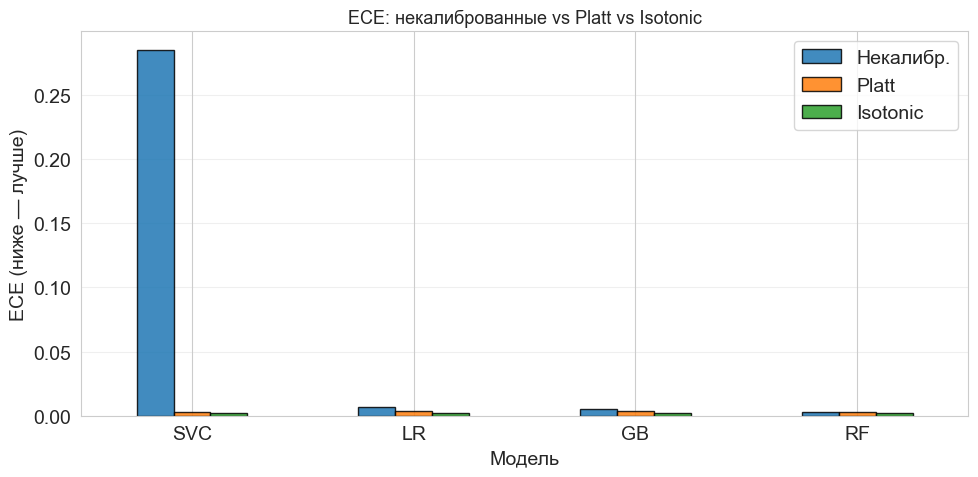

In [68]:
# Задание: посчитайте ECE для неоткалиброванного классификатора
print('=== ECE для неоткалиброванных классификаторов ===')
print('SVC (min-max):       ', binary_ECE(y_test, svc_pred))
print('Logistic Regression: ', binary_ECE(y_test, lr_pred))
print('Gradient Boosting:   ', binary_ECE(y_test, gb_pred))
print('Random Forest:       ', binary_ECE(y_test, rf_pred))

print()
print('=== Сравнение: Platt vs Isotonic vs Uncalibrated ===')

comparison = {
    'Модель': ['SVC', 'LR', 'GB', 'RF'],
    'Некалибр.':   [binary_ECE(y_test, svc_pred),
                    binary_ECE(y_test, lr_pred),
                    binary_ECE(y_test, gb_pred),
                    binary_ECE(y_test, rf_pred)],
    'Platt':        [binary_ECE(y_test, sigmoid_svc_pred),
                    binary_ECE(y_test, sigmoid_lr_pred),
                    binary_ECE(y_test, sigmoid_gb_pred),
                    binary_ECE(y_test, sigmoid_rf_pred)],
    'Isotonic':     [binary_ECE(y_test, isotonic_svc_pred),
                    binary_ECE(y_test, isotonic_lr_pred),
                    binary_ECE(y_test, isotonic_gb_pred),
                    binary_ECE(y_test, isotonic_rf_pred)],
}

df_ece = pd.DataFrame(comparison).set_index('Модель')
print(df_ece.round(5).to_string())

# Визуализация
df_ece.plot(kind='bar', figsize=(10, 5), edgecolor='black', alpha=0.85)
plt.title('ECE: некалиброванные vs Platt vs Isotonic', fontsize=13)
plt.ylabel('ECE (ниже — лучше)')
plt.xticks(rotation=0)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

**Вопрос**: Как можно адаптировать MCE/ECE для мультиклассовой задачи? Напишите формулы.
*Ответ*: использовать выигравший класс. Можно сделать бинарные есе для всех классов и потом усреднить по классам.

### Ответ: как адаптировать MCE/ECE для мультиклассовой задачи?

**Вариант 1 — Top-label ECE**:
Смотрим только на вероятность победившего класса $\hat{c} = \arg\max_j \hat{p}_j$:

$$\text{ECE}_{\text{top}} = \sum_{b=1}^B \frac{|\mathcal{B}_b|}{N} \left| \text{acc}(\mathcal{B}_b) - \text{conf}(\mathcal{B}_b) \right|$$

где $\mathcal{B}_b$ — бин по значению $\max_j \hat{p}_j(x_i)$, $\text{acc}(\mathcal{B}_b) = \frac{1}{|\mathcal{B}_b|} \sum_{i \in \mathcal{B}_b} \mathbb{1}[y_i = \hat{c}_i]$.

**Вариант 2 — Classwise ECE** (более строгий, маргинальный):
Для каждого класса $k$ считаем бинарный ECE в схеме one-vs-rest, затем усредняем:

$$\text{ECE}_{\text{classwise}} = \frac{1}{K} \sum_{k=1}^K \text{ECE}_{\text{binary}}^{(k)}$$

где $\text{ECE}_{\text{binary}}^{(k)}$ — ECE, где «позитивный» класс = класс $k$, а предсказанные вероятности = $\hat{p}_k(x_i)$.

В случае мультикласса, у нас возникает несколько сложностей: во-первых, в случае большого числа классов число бинов будет очень большим, при этом многие будут пустыми. Да и само определение реальной ECE пока не сделано. 

**Задание:** посчитайте ECE для модели, которая предсказывает пропорцию классов. Какие знаечения ECE и лосса у нее будут? Что изменится, если модель начнет предсказывать 0.9 для позитивных семплов и продолжит предсказывать пропорцию классов для негадивных?

In [69]:
# Задание: ECE для модели, предсказывающей пропорцию классов

# Доля положительного класса
pos_prop = y_test.mean()
print(f'Доля положительного класса: {pos_prop:.4f}')

# Модель 1: всегда предсказывает пропорцию классов
pred_const = np.full(len(y_test), pos_prop)

ece_const = binary_ECE(y_test, pred_const)
ll_const  = log_loss(y_test, pred_const)

print(f'\n=== Модель: predict = {pos_prop:.4f} для всех ===')
print(f'ECE:       {ece_const:.5f}')
print(f'Log-loss:  {ll_const:.5f}')

# Модель 2: 0.9 для позитивных, пропорция для негативных
pred_mixed = np.where(y_test == 1, 0.9, pos_prop)

ece_mixed = binary_ECE(y_test, pred_mixed)
ll_mixed  = log_loss(y_test, pred_mixed)

print(f'\n=== Модель: 0.9 для позитивных, {pos_prop:.3f} для негативных ===')
print(f'ECE:       {ece_mixed:.5f}')
print(f'Log-loss:  {ll_mixed:.5f}')

Доля положительного класса: 0.5485

=== Модель: predict = 0.5485 для всех ===
ECE:       0.00000
Log-loss:  0.68843

=== Модель: 0.9 для позитивных, 0.549 для негативных ===
ECE:       0.30250
Log-loss:  0.41682


Можно посчитать калиброванность и на уровне семплов.

**Brier score.** Тоже одна из популярных метрик, которая попросту измеряет разницу между предсказанными вероятностями и $ y_i $ (обратите внимание, что $ y_i $  - это либо 0, либо 1):
$$ \sum^N_{i=1}(y_i - q (x_i))^2,$$ 
для бинарного случая, и
$$ {1 \over N} \sum^N_{n=1}\sum^K_{j=1} (I(y_n=j) - q_{nj})^2,$$ 
для мультикласса.

**Вопрос**: Какое значение соответствует лучшей калибрации? Какие максимальные и минимальные значения он можеит принимать?

### Ответ: что означают значения Brier Score?

$$\text{BS} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{p}(x_i))^2$$

**Лучшее значение — 0**: достигается при $\hat{p}(x_i) = y_i$ (то есть $\hat{p}=1$ для позитивных и $\hat{p}=0$ для негативных).

**Диапазон значений:**
- **Минимум = 0** — идеальная модель, всегда уверена и права
- **Максимум = 1** — катастрофическая модель: предсказывает $\hat{p}=1$ там, где $y=0$ и наоборот
- **Базовый уровень** (константная модель $\hat{p} = \bar{y}$): $\text{BS} = \bar{y}(1-\bar{y})$,   при сбалансированных классах ≈ 0.25

**Интерпретация:**
- BS < 0.1 — отличная калибровка
- BS ≈ 0.25 — модель не лучше константы при 50/50 балансе
- BS > 0.25 — модель хуже наивного классификатора

Также можно использовать log-loss:
$$ {-1\over N} {\sum^N_{n=1}\sum^K_{j=1}I(y_n=j)log(q_{n,j})}$$

Для достаточно гладких классификатора и датасета brier score и log-loss будут адекватными средствами оценки, но если нет — возможно всякое.

In [70]:
print('Log-loss (ниже — лучше):')
print('Platt SVC =', log_loss(y_test, np.column_stack([1 - sigmoid_svc_pred, sigmoid_svc_pred])))
print('Platt LR =', log_loss(y_test, np.column_stack([1 - sigmoid_lr_pred, sigmoid_lr_pred])))
print('Platt GB =', log_loss(y_test, np.column_stack([1 - sigmoid_gb_pred, sigmoid_gb_pred])))
print('Platt RF =', log_loss(y_test, np.column_stack([1 - sigmoid_rf_pred, sigmoid_rf_pred])))
print('Isotonic SVC =', log_loss(y_test, np.column_stack([1 - isotonic_svc_pred, isotonic_svc_pred])))
print('Isotonic LR =', log_loss(y_test, np.column_stack([1 - isotonic_lr_pred, isotonic_lr_pred])))
print('Isotonic GB =', log_loss(y_test, np.column_stack([1 - isotonic_gb_pred, isotonic_gb_pred])))
print('Isotonic RF =', log_loss(y_test, np.column_stack([1 - isotonic_rf_pred, isotonic_rf_pred])))

Log-loss (ниже — лучше):
Platt SVC = 0.031276285531776374
Platt LR = 0.0333262455198998
Platt GB = 0.03331647881716411
Platt RF = 0.038908642002126646
Isotonic SVC = 0.030862017942066812
Isotonic LR = 0.033625055910619976
Isotonic GB = 0.03191541409933446
Isotonic RF = 0.0317766445159259


In [71]:
print("Platt:")
print('SVC brier score = ', brier_score_loss(y_test, sigmoid_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, sigmoid_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, sigmoid_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, sigmoid_rf_pred, pos_label=1))

print("Isotonic:")
print('SVC brier score = ', brier_score_loss(y_test, isotonic_svc_pred, pos_label=1))
print('Linear brier score = ', brier_score_loss(y_test, isotonic_lr_pred, pos_label=1))
print('GB brier score = ', brier_score_loss(y_test, isotonic_gb_pred, pos_label=1))
print('RF brier score = ', brier_score_loss(y_test, isotonic_rf_pred, pos_label=1))

Platt:
SVC brier score =  0.008190798964877335
Linear brier score =  0.008657533565358946
GB brier score =  0.008325371462496654
RF brier score =  0.008416712034272293
Isotonic:
SVC brier score =  0.008210667087989345
Linear brier score =  0.008753390327467452
GB brier score =  0.008318772289237032
RF brier score =  0.008147859165350083


**Задание**: Посчитайте метрику для неоткалиброванного классификатора.

In [72]:
# Задание: посчитайте метрики для неоткалиброванного классификатора
print('=== Brier Score (ниже — лучше) ===')
print('Некалиброванные:')
print('  SVC:        ', brier_score_loss(y_test, svc_pred,  pos_label=1))
print('  LR:         ', brier_score_loss(y_test, lr_pred,   pos_label=1))
print('  GB:         ', brier_score_loss(y_test, gb_pred,   pos_label=1))
print('  RF:         ', brier_score_loss(y_test, rf_pred,   pos_label=1))

print('\nPlatt:')
print('  SVC:        ', brier_score_loss(y_test, sigmoid_svc_pred, pos_label=1))
print('  LR:         ', brier_score_loss(y_test, sigmoid_lr_pred,  pos_label=1))
print('  GB:         ', brier_score_loss(y_test, sigmoid_gb_pred,  pos_label=1))
print('  RF:         ', brier_score_loss(y_test, sigmoid_rf_pred,  pos_label=1))

print('\nIsotonic:')
print('  SVC:        ', brier_score_loss(y_test, isotonic_svc_pred, pos_label=1))
print('  LR:         ', brier_score_loss(y_test, isotonic_lr_pred,  pos_label=1))
print('  GB:         ', brier_score_loss(y_test, isotonic_gb_pred,  pos_label=1))
print('  RF:         ', brier_score_loss(y_test, isotonic_rf_pred,  pos_label=1))

print('\n=== Log-loss (ниже — лучше) ===')
print('Некалиброванные:')
print('  SVC:', log_loss(y_test, np.column_stack([1-svc_pred, svc_pred])))
print('  LR: ', log_loss(y_test, np.column_stack([1-lr_pred,  lr_pred])))
print('  GB: ', log_loss(y_test, np.column_stack([1-gb_pred,  gb_pred])))
print('  RF: ', log_loss(y_test, np.column_stack([1-rf_pred,  rf_pred])))

=== Brier Score (ниже — лучше) ===
Некалиброванные:
  SVC:         0.10358435719849597
  LR:          0.008708760194226426
  GB:          0.008841058951713502
  RF:          0.00812029049534167

Platt:
  SVC:         0.008190798964877335
  LR:          0.008657533565358946
  GB:          0.008325371462496654
  RF:          0.008416712034272293

Isotonic:
  SVC:         0.008210667087989345
  LR:          0.008753390327467452
  GB:          0.008318772289237032
  RF:          0.008147859165350083

=== Log-loss (ниже — лучше) ===
Некалиброванные:
  SVC: 0.36851995253391706
  LR:  0.03438447807862264
  GB:  0.04592452509990291
  RF:  0.03145438130950179


Итак, мы откалибровали наши классификаторы. Теперь мы можем оценить, как поменяются метрики после этого. Так, по идее точность, f1 не должны сильно поменяться, так как вблизи от границы разделения вероятности не должны сильно измениться. Так ли это?
Теперь **вопрос**: Изменится ли после калибрации ROC-AUC и как? Можете ли вы ответить на вопрос без измерений?

## Изменится ли ROC-AUC после калибровки?

**Нет, ROC-AUC практически не изменится.**

ROC-AUC зависит только от ранжирования объектов, а не от самих значений вероятностей.

### Почему:
- Калибровка (Platt, isotonic) — это монотонное преобразование (или почти монотонное).
- Она не меняет порядок объектов, а только их вероятности.

### Следствие:
- ROC-AUC остаётся тем же, потому что пары positive/negative упорядочены одинаково.

### Исключения (редко):
- возможны микросдвиги при isotonic из-за выравнивания значений
- tied scores могут немного влиять

## Итог:
ROC-AUC после калибровки почти не меняется

**Задание**: Обучите дерево решений и случайный лес.

In [73]:
# Задание: обучите дерево решений и случайный лес

# 1) Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=SEED)
dt.fit(X_train, y_train)

dt_pred = dt.predict_proba(X_test)[:, 1]
dt_roc  = roc_auc_score(y_test, dt_pred)
dt_ece  = binary_ECE(y_test, dt_pred)
dt_bs   = brier_score_loss(y_test, dt_pred)

print(f'Decision Tree  | ROC-AUC: {dt_roc:.4f} | ECE: {dt_ece:.4f} | Brier: {dt_bs:.4f}')

# 2) Random Forest
rf2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED)
rf2.fit(X_train, y_train)

rf2_pred = rf2.predict_proba(X_test)[:, 1]
rf2_roc  = roc_auc_score(y_test, rf2_pred)
rf2_ece  = binary_ECE(y_test, rf2_pred)
rf2_bs   = brier_score_loss(y_test, rf2_pred)

print(f'Random Forest  | ROC-AUC: {rf2_roc:.4f} | ECE: {rf2_ece:.4f} | Brier: {rf2_bs:.4f}')

# Сводная таблица до калибровки
print()
summary_rows = [
    ('SVC',  roc_auc_score(y_test, svc_pred), binary_ECE(y_test, svc_pred), brier_score_loss(y_test, svc_pred)),
    ('LR',   roc_auc_score(y_test, lr_pred),  binary_ECE(y_test, lr_pred),  brier_score_loss(y_test, lr_pred)),
    ('GB',   roc_auc_score(y_test, gb_pred),  binary_ECE(y_test, gb_pred),  brier_score_loss(y_test, gb_pred)),
    ('RF',   roc_auc_score(y_test, rf_pred),  binary_ECE(y_test, rf_pred),  brier_score_loss(y_test, rf_pred)),
    ('DT',   dt_roc, dt_ece, dt_bs),
    ('RF2',  rf2_roc, rf2_ece, rf2_bs),
]
df_summary = pd.DataFrame(summary_rows, columns=['Model', 'ROC-AUC', 'ECE', 'Brier'])
print('=== До калибровки ===')
print(df_summary.to_string(index=False))

Decision Tree  | ROC-AUC: 0.9871 | ECE: 0.0133 | Brier: 0.0138
Random Forest  | ROC-AUC: 0.9991 | ECE: 0.0026 | Brier: 0.0081

=== До калибровки ===
Model  ROC-AUC      ECE    Brier
  SVC 0.999145 0.285346 0.103584
   LR 0.999002 0.006612 0.008709
   GB 0.998357 0.005609 0.008841
   RF 0.999101 0.002561 0.008120
   DT 0.987143 0.013292 0.013761
  RF2 0.999101 0.002561 0.008120


**Задание**: Откалибройте изотоническим методом. Постройте калибровочные кривые для классификаторов, до и после калибровки.

In [74]:
# Задание: откалибруйте изотоническим и Platt методами

# --- Decision Tree ---
dt_isotonic = CalibratedClassifierCV(dt, cv=3, method='isotonic').fit(X_train, y_train)
dt_sigmoid  = CalibratedClassifierCV(dt, cv=3, method='sigmoid').fit(X_train, y_train)

dt_iso_pred = dt_isotonic.predict_proba(X_test)[:, 1]
dt_sig_pred = dt_sigmoid.predict_proba(X_test)[:, 1]

print('Decision Tree | ROC-AUC:')
print(f'  Uncalibrated: {roc_auc_score(y_test, dt_pred):.4f}')
print(f'  Isotonic:     {roc_auc_score(y_test, dt_iso_pred):.4f}')
print(f'  Platt:        {roc_auc_score(y_test, dt_sig_pred):.4f}')

print()
# --- Random Forest ---
rf2_isotonic = CalibratedClassifierCV(rf2, cv=3, method='isotonic').fit(X_train, y_train)
rf2_sigmoid  = CalibratedClassifierCV(rf2, cv=3, method='sigmoid').fit(X_train, y_train)

rf2_iso_pred = rf2_isotonic.predict_proba(X_test)[:, 1]
rf2_sig_pred = rf2_sigmoid.predict_proba(X_test)[:, 1]

print('Random Forest | ROC-AUC:')
print(f'  Uncalibrated: {roc_auc_score(y_test, rf2_pred):.4f}')
print(f'  Isotonic:     {roc_auc_score(y_test, rf2_iso_pred):.4f}')
print(f'  Platt:        {roc_auc_score(y_test, rf2_sig_pred):.4f}')

Decision Tree | ROC-AUC:
  Uncalibrated: 0.9871
  Isotonic:     0.9945
  Platt:        0.9944

Random Forest | ROC-AUC:
  Uncalibrated: 0.9991
  Isotonic:     0.9991
  Platt:        0.9991


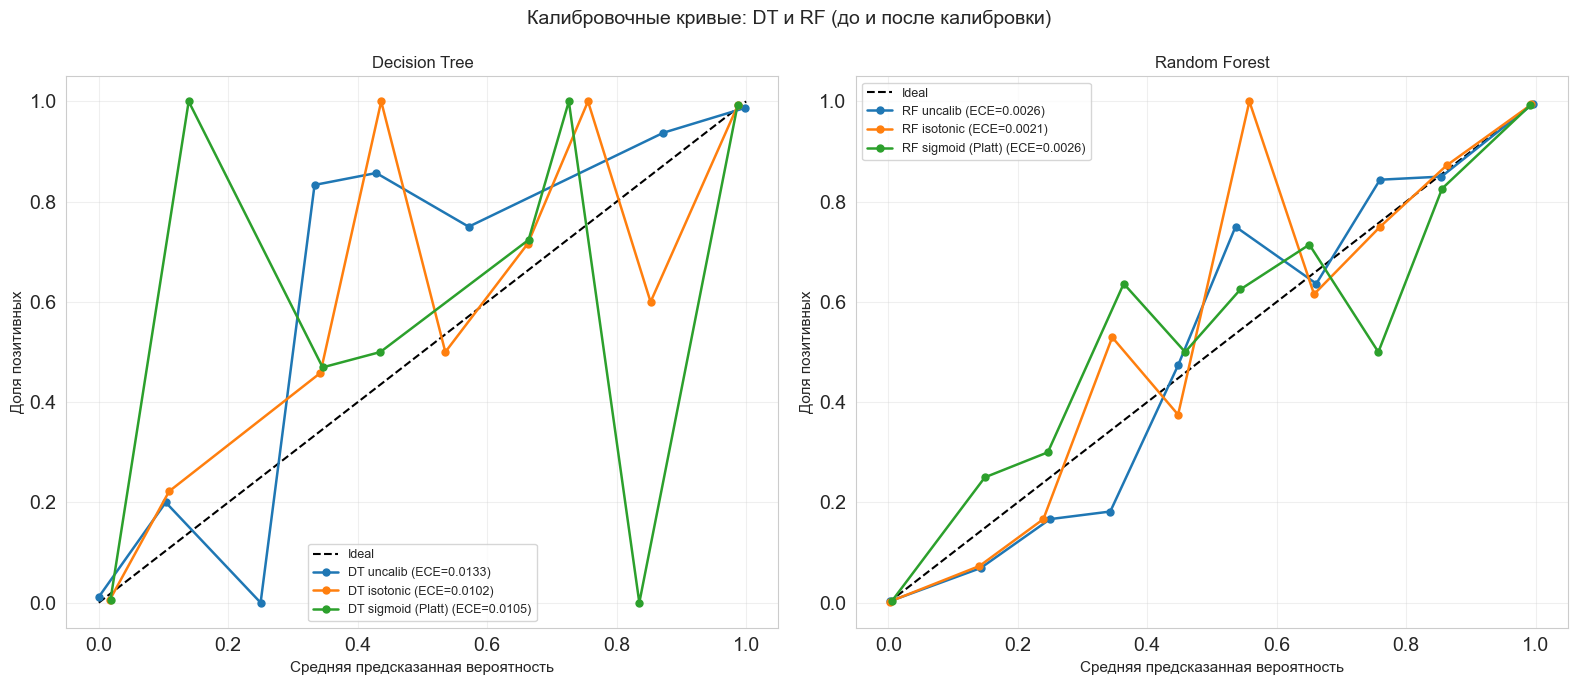

In [75]:
# Задание: калибровочные кривые до и после калибровки
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Калибровочные кривые: DT и RF (до и после калибровки)', fontsize=14)

for ax, title, preds in [
    (axes[0], 'Decision Tree', [
        ('DT uncalib', dt_pred),
        ('DT isotonic', dt_iso_pred),
        ('DT sigmoid (Platt)', dt_sig_pred),
    ]),
    (axes[1], 'Random Forest', [
        ('RF uncalib', rf2_pred),
        ('RF isotonic', rf2_iso_pred),
        ('RF sigmoid (Platt)', rf2_sig_pred),
    ]),
]:
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Ideal')
    for name, pred in preds:
        true_p, pred_p = calibration_curve(y_test, pred, n_bins=10)
        ece = binary_ECE(y_test, pred)
        ax.plot(pred_p, true_p, marker='o', ms=5, lw=1.8,
                label=f'{name} (ECE={ece:.4f})')
    ax.set_xlabel('Средняя предсказанная вероятность', fontsize=11)
    ax.set_ylabel('Доля позитивных', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

ВОпрос: Какой вывод можно сделать из графиков?

### Ответ: какой вывод можно сделать из графиков?

- Random Forest изначально хорошо откалиброван (низкий ECE), калибровка почти не дает улучшений.
- Decision Tree плохо откалиброван (нестабильные вероятности, выше ECE).
- Калибровка (isotonic и platt) заметно улучшает Decision Tree.
- Разница между isotonic и platt небольшая, isotonic чуть лучше.
- Калибровка особенно важна для простых моделей, если используются вероятности.

**Задание**: Какой из классификаторов в итоге лучше откалиброван (среди всех)? Покажите в сравнении. Какой вы выберете далее?

=== Все модели (отсортировано по ECE) ===
       Model  ROC-AUC     ECE   Brier  Log-loss
 RF Isotonic  0.99913 0.00206 0.00815   0.03178
SVC Isotonic  0.99910 0.00209 0.00821   0.03086
 LR Isotonic  0.99894 0.00215 0.00875   0.03363
 GB Isotonic  0.99900 0.00228 0.00832   0.03192
    RF (raw)  0.99910 0.00256 0.00812   0.03145
    RF Platt  0.99908 0.00261 0.00842   0.03891
   SVC Platt  0.99913 0.00278 0.00819   0.03128
    LR Platt  0.99898 0.00345 0.00866   0.03333
    GB Platt  0.99906 0.00347 0.00833   0.03332
    GB (raw)  0.99836 0.00561 0.00884   0.04592
    LR (raw)  0.99900 0.00661 0.00871   0.03438
 DT Isotonic  0.99452 0.01019 0.01075   0.05315
    DT Platt  0.99443 0.01052 0.01086   0.05434
    DT (raw)  0.98714 0.01329 0.01376   0.40311
   SVC (raw)  0.99915 0.28535 0.10358   0.36852


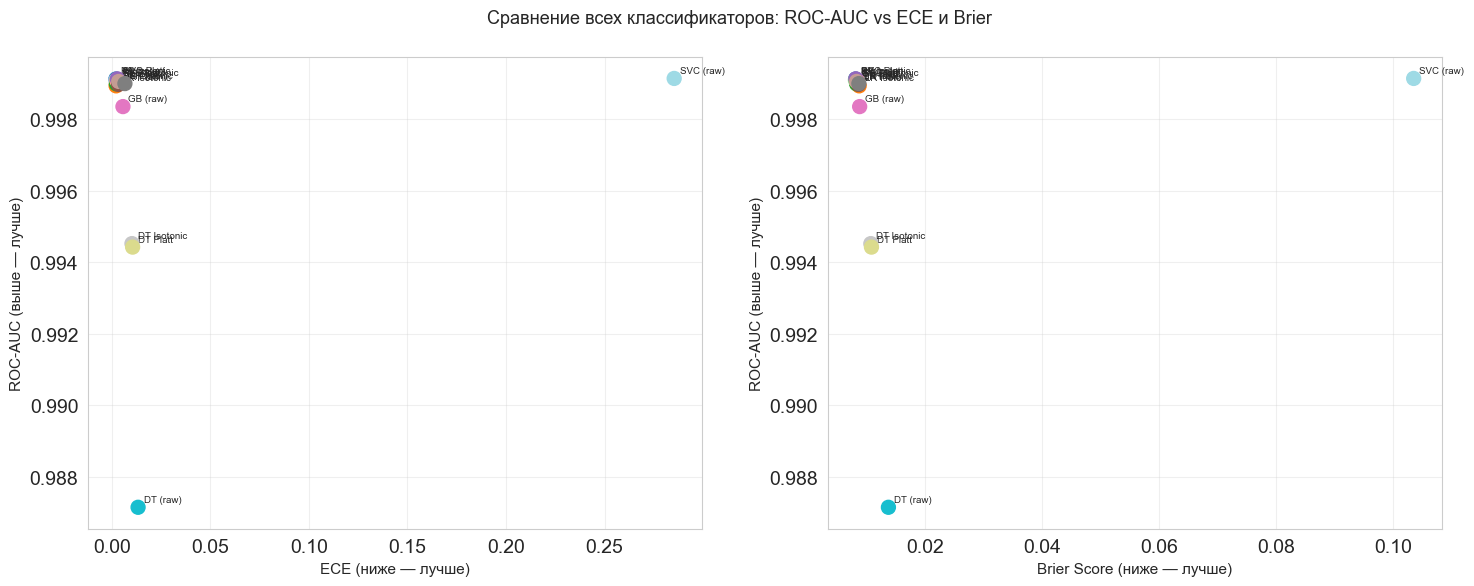


Лучшая калибровка по ECE: RF Isotonic
  ECE=0.00206, ROC-AUC=0.9991, Brier=0.00815


In [76]:
# Задание: какой из классификаторов лучше откалиброван?

# Собираем все модели и их метрики
all_models = {
    'SVC (raw)':        svc_pred,
    'LR (raw)':         lr_pred,
    'GB (raw)':         gb_pred,
    'RF (raw)':         rf_pred,
    'DT (raw)':         dt_pred,
    'SVC Platt':        sigmoid_svc_pred,
    'LR Platt':         sigmoid_lr_pred,
    'GB Platt':         sigmoid_gb_pred,
    'RF Platt':         sigmoid_rf_pred,
    'DT Platt':         dt_sig_pred,
    'SVC Isotonic':     isotonic_svc_pred,
    'LR Isotonic':      isotonic_lr_pred,
    'GB Isotonic':      isotonic_gb_pred,
    'RF Isotonic':      isotonic_rf_pred,
    'DT Isotonic':      dt_iso_pred,
}

rows = []
for name, pred in all_models.items():
    rows.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, pred),
        'ECE': binary_ECE(y_test, pred),
        'Brier': brier_score_loss(y_test, pred),
        'Log-loss': log_loss(y_test, np.column_stack([1-pred, pred])),
    })

df_all = pd.DataFrame(rows).sort_values('ECE')

print('=== Все модели (отсортировано по ECE) ===')
print(df_all.round(5).to_string(index=False))

# Визуализация — scatter ECE vs ROC-AUC
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Сравнение всех классификаторов: ROC-AUC vs ECE и Brier', fontsize=13)

scatter_colors = plt.cm.tab20(np.linspace(0, 1, len(df_all)))
for ax, xcol, xlab in [
    (axes[0], 'ECE',   'ECE (ниже — лучше)'),
    (axes[1], 'Brier', 'Brier Score (ниже — лучше)'),
]:
    sc = ax.scatter(df_all[xcol], df_all['ROC-AUC'],
                    c=range(len(df_all)), cmap='tab20', s=100, zorder=5)
    for _, row in df_all.iterrows():
        ax.annotate(row['Model'], (row[xcol], row['ROC-AUC']),
                    fontsize=7, textcoords='offset points', xytext=(4, 4))
    ax.set_xlabel(xlab, fontsize=11)
    ax.set_ylabel('ROC-AUC (выше — лучше)', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

best = df_all.iloc[0]
print(f'\nЛучшая калибровка по ECE: {best["Model"]}')
print(f'  ECE={best["ECE"]:.5f}, ROC-AUC={best["ROC-AUC"]:.4f}, Brier={best["Brier"]:.5f}')

Больше информации - в [отличном туториале](https://classifier-calibration.github.io/ecml-pkdd-2020-tutorial/) и [материалах Дьяконова](https://web.archive.org/web/20240315204907/https://alexanderdyakonov.wordpress.com/2020/03/27/%D0%BF%D1%80%D0%BE%D0%B1%D0%BB%D0%B5%D0%BC%D0%B0-%D0%BA%D0%B0%D0%BB%D0%B8%D0%B1%D1%80%D0%BE%D0%B2%D0%BA%D0%B8-%D1%83%D0%B2%D0%B5%D1%80%D0%B5%D0%BD%D0%BD%D0%BE%D1%81%D1%82%D0%B8/).